### ML PROJECT DATASET 2

In [ ]:
print(data['Y'].unique())
print(data['Y'].value_counts())


[1 0]
Y
0    23364
1     6638
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Assuming the features are X1, X2, ..., X21 and the target variable is Y
column_names = [f'X{i}' for i in range(1, 22)] + ['Y']  # Creating column names X1, X2, ..., X21, and Y as the target variable

# Load the dataset
file_path = 'taiwan.xls'
data = pd.read_excel('taiwan.xls', header=None, names=column_names, na_values='?')

# Display basic info
print(data.head())  # First 5 rows of the data
print(data.info())  # Basic info about the dataset (types and missing values)

# Separating features (X) and target (Y)
X = data.drop('Y', axis=1)  # Features (X1, X2, ..., X21)
Y = data['Y']  # Target variable (Y)

# Display the first few rows of X and Y to verify
print(X.head())
print(Y.head())


                          X1        X2   X3     X4     X5     X6     X7  \
NaN X1        X2          X3        X4   X5     X6     X7     X8     X9   
ID  LIMIT_BAL SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4   
1   20000     2            2         1   24      2      2     -1     -1   
2   120000    2            2         2   26     -1      2      0      0   
3   90000     2            2         2   34      0      0      0      0   

                      X8     X9        X10  ...        X13        X14  \
NaN X1        X2     X10    X11        X12  ...        X15        X16   
ID  LIMIT_BAL SEX  PAY_5  PAY_6  BILL_AMT1  ...  BILL_AMT4  BILL_AMT5   
1   20000     2       -2     -2       3913  ...          0          0   
2   120000    2        0      2       2682  ...       3272       3455   
3   90000     2        0      0      29239  ...      14331      14948   

                         X15       X16       X17       X18       X19  \
NaN X1        X2         X17       X18

In [ ]:
from sklearn.impute import SimpleImputer

# Separate numerical and categorical columns
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = data.select_dtypes(include=['object']).columns

# Impute missing values
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

data[numerical_cols] = num_imputer.fit_transform(data[numerical_cols])
data[categorical_cols] = cat_imputer.fit_transform(data[categorical_cols])

# Confirm no missing values
print(data.isnull().sum())


X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
Y      0
dtype: int64


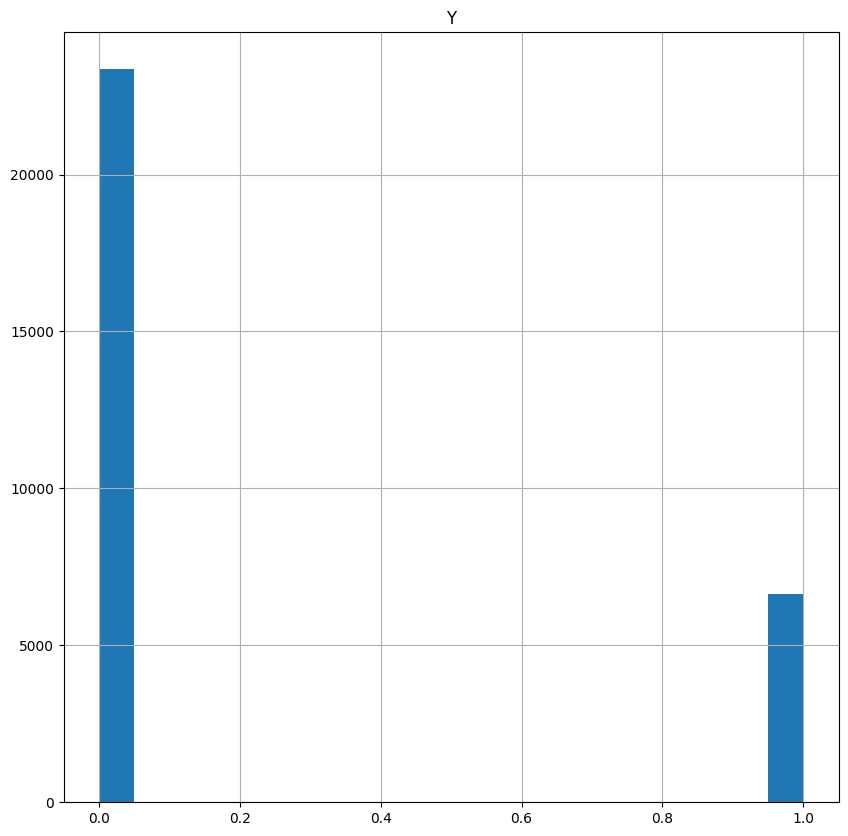

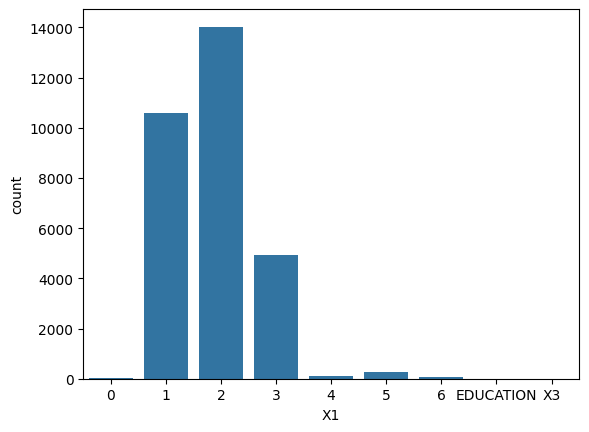

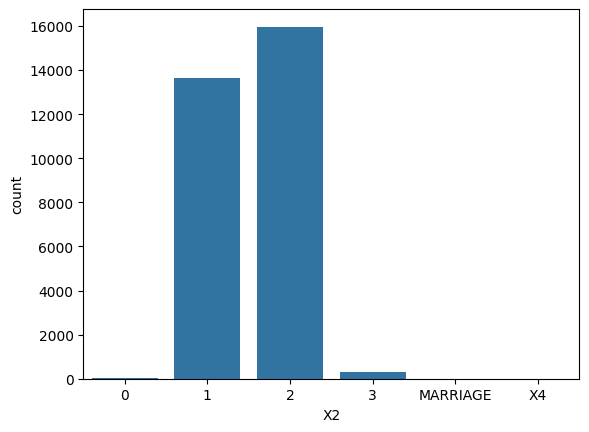

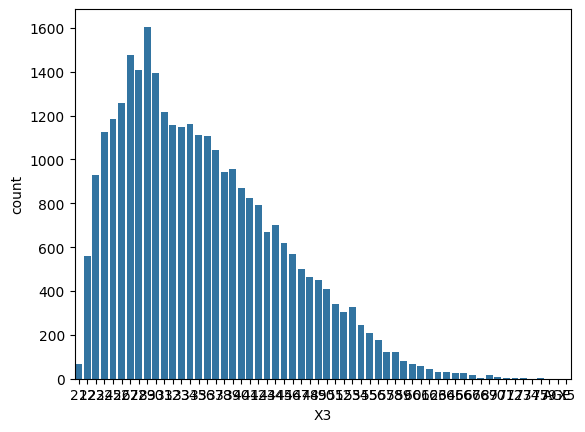

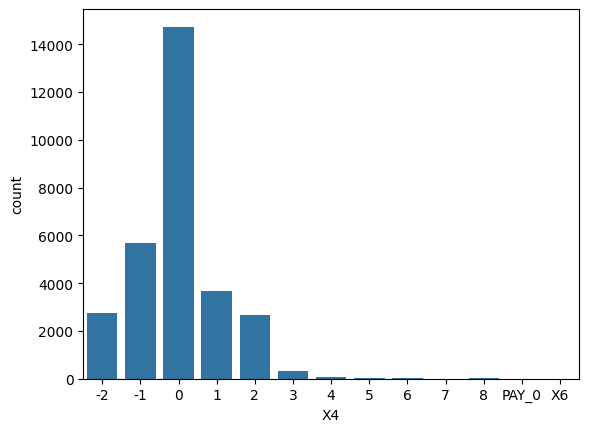

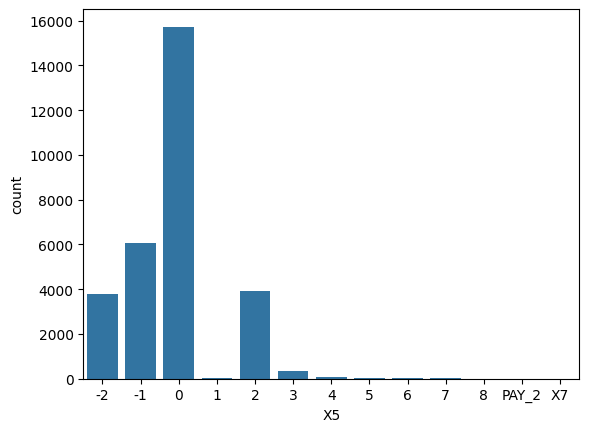

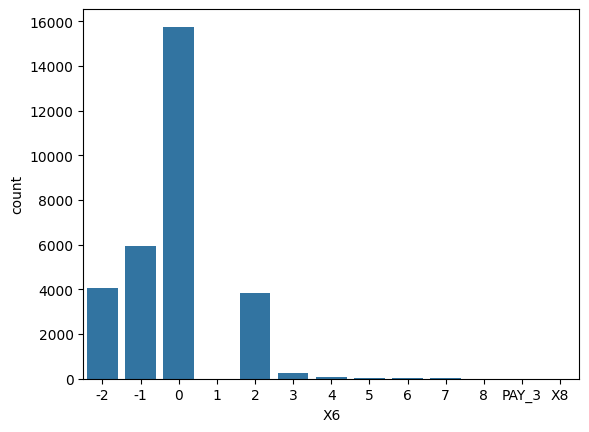

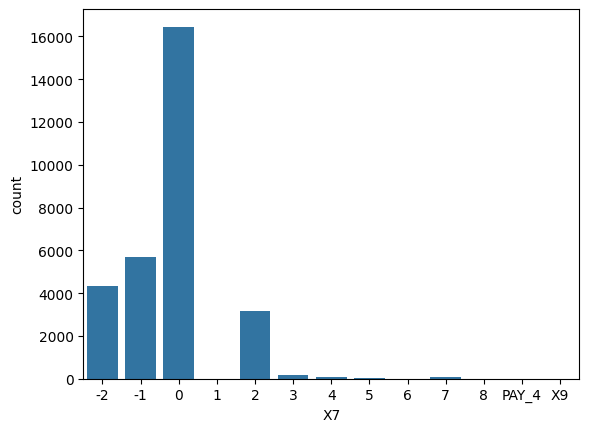

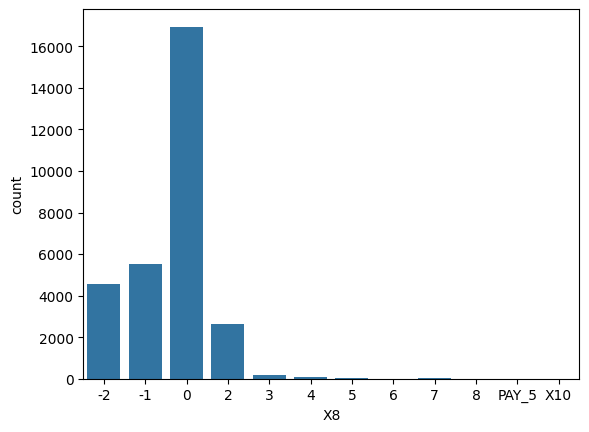

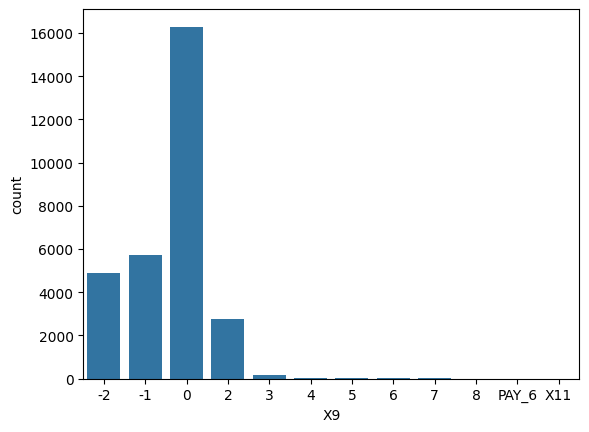

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Make sure pandas is imported

# Visualize numerical data
data[numerical_cols].hist(bins=20, figsize=(10, 10))
plt.show()

# Visualize categorical data
# Ensure categorical_cols is a list of strings
categorical_cols = [col for col in categorical_cols if isinstance(col, str)]

for col in categorical_cols:
    # Convert the column to a categorical data type
    data[col] = pd.Categorical(data[col]) # convert to categorical

    sns.countplot(x=col, data=data) # Specify x and data parameters explicitly
    plt.show()

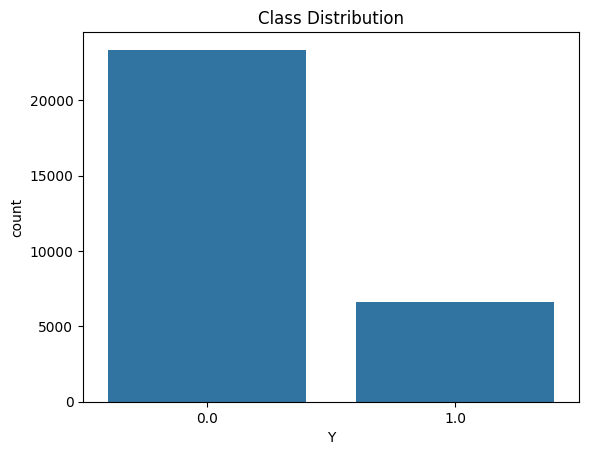

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Make sure pandas is imported

# ... (Your existing code for data loading and preprocessing) ...

# Ensure 'Y' is treated as categorical
data['Y'] = pd.Categorical(data['Y'])  # Explicitly convert 'Y' to categorical

sns.countplot(x='Y', data=data)  # Specify 'x=' to use 'Y' as the categorical axis
plt.title("Class Distribution")
plt.show()

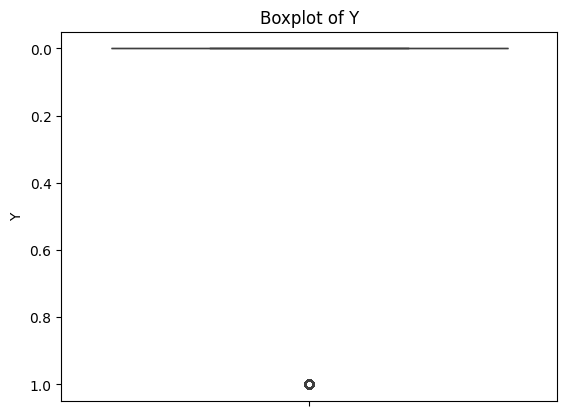

In [ ]:
for col in numerical_cols:
    sns.boxplot(data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()



In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical columns
label_encoders = {}
for col in categorical_cols:
    # Convert the column to string type before encoding
    data[col] = data[col].astype(str)
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

In [ ]:
from sklearn.model_selection import train_test_split

# Features and target
X = data.drop('Y', axis=1)
y = data['Y']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (24001, 21)
Test set size: (6001, 21)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

lr_predictions = lr.predict(X_test)
lr_probabilities = lr.predict_proba(X_test)[:, 1]  # For AUC-ROC

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree model
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# Make predictions
dt_predictions = dt.predict(X_test)
dt_probabilities = dt.predict_proba(X_test)[:, 1]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Make predictions
rf_predictions = rf.predict(X_test)
rf_probabilities = rf.predict_proba(X_test)[:, 1]


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train the Gradient Boosting model
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

# Make predictions
gb_predictions = gb.predict(X_test)
gb_probabilities = gb.predict_proba(X_test)[:, 1]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Function to calculate evaluation metrics
def evaluate_model(y_test, predictions, prob_predictions):
    metrics = {
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions),
        'Recall': recall_score(y_test, predictions),
        'F1 Score': f1_score(y_test, predictions),
        'AUC-ROC': roc_auc_score(y_test, prob_predictions)
    }
    return metrics

# Evaluate each model
models = {
    "Logistic Regression": (lr_predictions, lr_probabilities),
    "Decision Tree": (dt_predictions, dt_probabilities),
    "Random Forest": (rf_predictions, rf_probabilities),
    "Gradient Boosting": (gb_predictions, gb_probabilities)
}

results = {}
for model_name, (predictions, probabilities) in models.items():
    results[model_name] = evaluate_model(y_test, predictions, probabilities)

# Display results
import pandas as pd
results_df = pd.DataFrame(results).T
print(results_df)


                     Accuracy  Precision    Recall  F1 Score   AUC-ROC
Logistic Regression  0.796367   0.628272  0.181818  0.282021  0.690465
Decision Tree        0.711881   0.361544  0.404545  0.381838  0.605180
Random Forest        0.816031   0.644772  0.364394  0.465634  0.738778
Gradient Boosting    0.825696   0.700880  0.362121  0.477522  0.768236


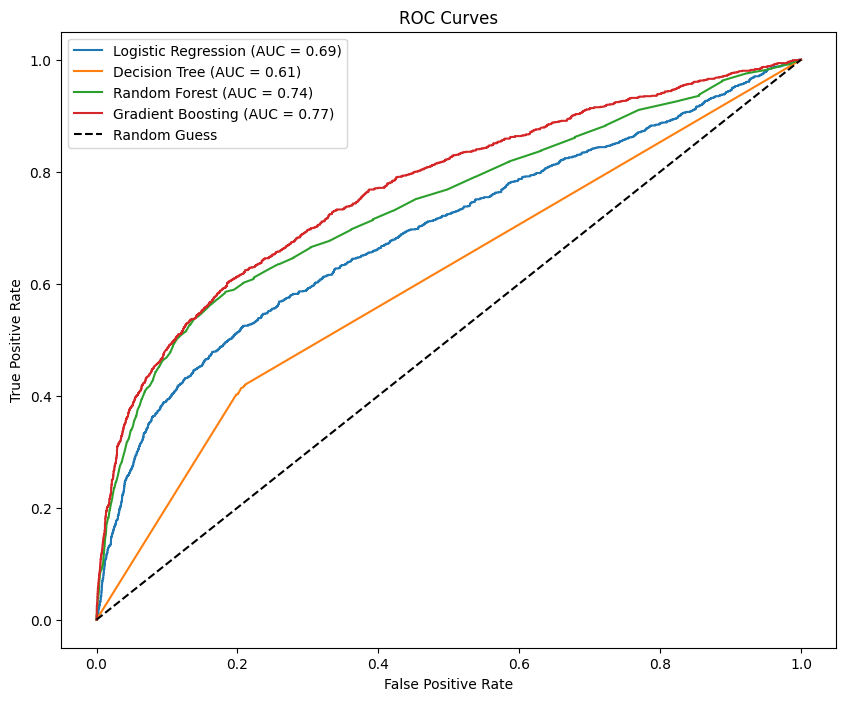

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Plot ROC curve for each model
plt.figure(figsize=(10, 8))
for model_name, (predictions, probabilities) in models.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc_score(y_test, probabilities):.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()
